## **Data Science Aplicado a las Finanzas** 🚀
### **HW Sesión 2 — Tarea 2**

Trabajo desarrollado en Python para analizar retornos, riesgo, correlaciones, tests estadísticos, distribuciones muestrales y estimación por máxima verosimilitud usando activos tecnológicos y financieros.

In [3]:
# Librerías necesarias
from matplotlib import pyplot as plt
from scipy.stats import f_oneway, mannwhitneyu, kruskal, levene, bartlett
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

sns.set_style("dark")
np.random.seed(20260607)

---
## Parte I: Transformación de Datos Financieros *(25 puntos)*

Portafolio para el período **2021-01-01** al **2024-12-31**:

| Ticker | Empresa |
|--------|--------|
| AAPL | Apple Inc. |
| AMZN | Amazon.com Inc. |
| JPM | JPMorgan Chase & Co. |
| GS | Goldman Sachs Group Inc. |
| TSLA | Tesla Inc. |

### Pregunta 1.1 — Retornos Simples y Logarítmicos *(8 puntos)*

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GS,JPM,TSLA
Date,,,,,
2021-01-04,125.740852,159.331497,233.060974,109.491562,243.256668
2021-01-05,127.295486,160.925507,238.276245,110.087326,245.036667
2021-01-06,123.010521,156.919006,251.134048,115.256577,251.993332
2021-01-07,127.208046,158.108002,256.498901,119.041550,272.013336
2021-01-08,128.306015,159.134995,255.118210,119.172958,293.339996


Retornos simples:


Ticker,AAPL,AMZN,GS,JPM,TSLA
Date,,,,,
2021-01-05,0.012364,0.010004,0.022377,0.005441,0.007317
2021-01-06,-0.033662,-0.024897,0.053962,0.046956,0.028390
2021-01-07,0.034123,0.007577,0.021363,0.032840,0.079447
2021-01-08,0.008631,0.006496,-0.005383,0.001104,0.078403
2021-01-11,-0.023249,-0.021519,0.012927,0.014924,-0.078214


Retornos logarítmicos:


Ticker,AAPL,AMZN,GS,JPM,TSLA
Date,,,,,
2021-01-05,0.012288,0.009955,0.022131,0.005426,0.007291
2021-01-06,-0.034241,-0.025212,0.052556,0.045887,0.027995
2021-01-07,0.033554,0.007549,0.021138,0.032312,0.076448
2021-01-08,0.008594,0.006475,-0.005397,0.001103,0.075481
2021-01-11,-0.023523,-0.021754,0.012844,0.014814,-0.081442


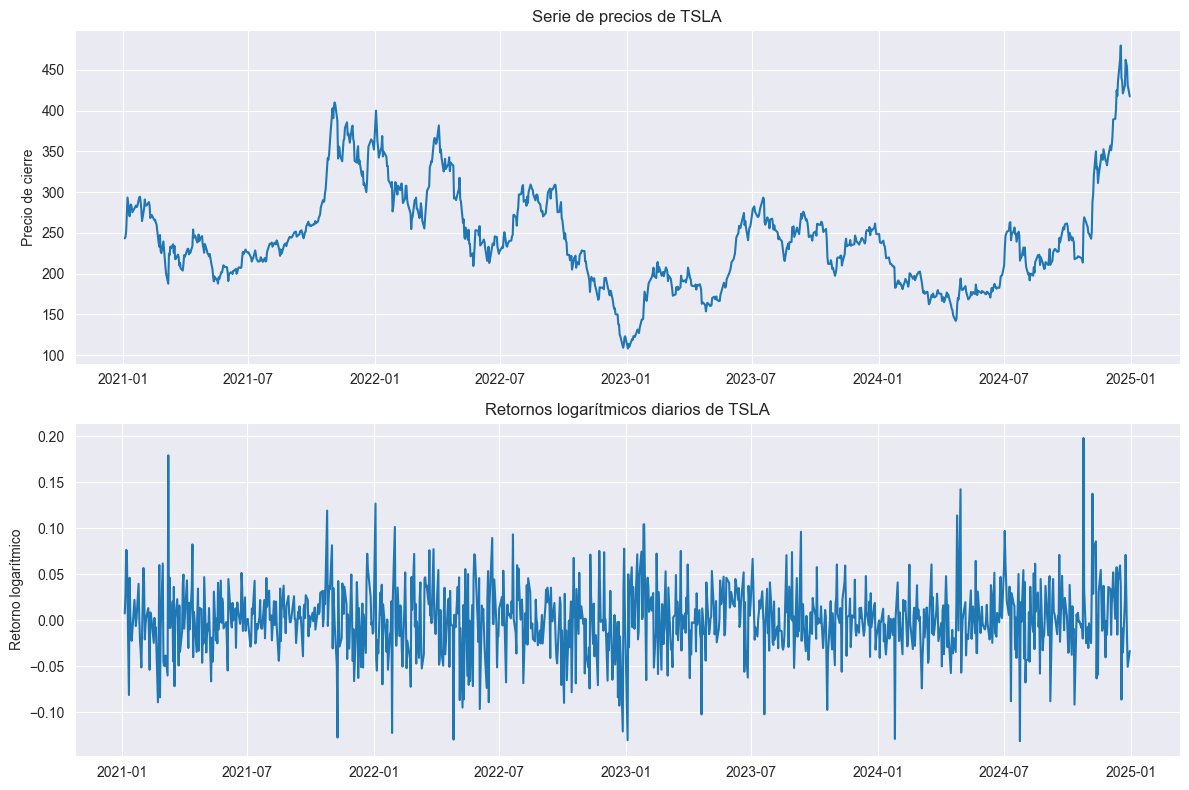

In [4]:
# Pregunta 1.1
# a) Descargar precios de cierre

tickers = ["AAPL", "AMZN", "JPM", "GS", "TSLA"]
fecha_inicio = "2021-01-01"
fecha_fin = "2024-12-31"

datos = yf.download(tickers, start=fecha_inicio, end=fecha_fin, auto_adjust=True)
precios = datos["Close"].dropna()

display(precios.head())

# b) Retornos diarios simples y logarítmicos
retornos_simples = precios.pct_change().dropna()
retornos_log = np.log(precios / precios.shift(1)).dropna()

print("Retornos simples:")
display(retornos_simples.head())

print("Retornos logarítmicos:")
display(retornos_log.head())

# c) Gráfico TSLA: precios y retornos logarítmicos
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(precios.index, precios["TSLA"])
ax[0].set_title("Serie de precios de TSLA")
ax[0].set_ylabel("Precio de cierre")
ax[0].grid(True)

ax[1].plot(retornos_log.index, retornos_log["TSLA"])
ax[1].set_title("Retornos logarítmicos diarios de TSLA")
ax[1].set_ylabel("Retorno logarítmico")
ax[1].grid(True)

plt.tight_layout()
plt.show()

**Respuesta 1.1d:**  
Los retornos simples muestran el cambio porcentual directo entre dos precios consecutivos. Los retornos logarítmicos usan el logaritmo natural de la razón entre precios consecutivos. Cuando los cambios son pequeños, ambos retornos son muy similares, pero ante variaciones grandes pueden diferir más. Los retornos logarítmicos son convenientes en análisis financiero porque son aditivos en el tiempo, facilitan la modelación estadística y permiten trabajar de mejor forma con volatilidad, riesgo y acumulación de retornos.

### Pregunta 1.2 — Retornos Multi-Período *(9 puntos)*

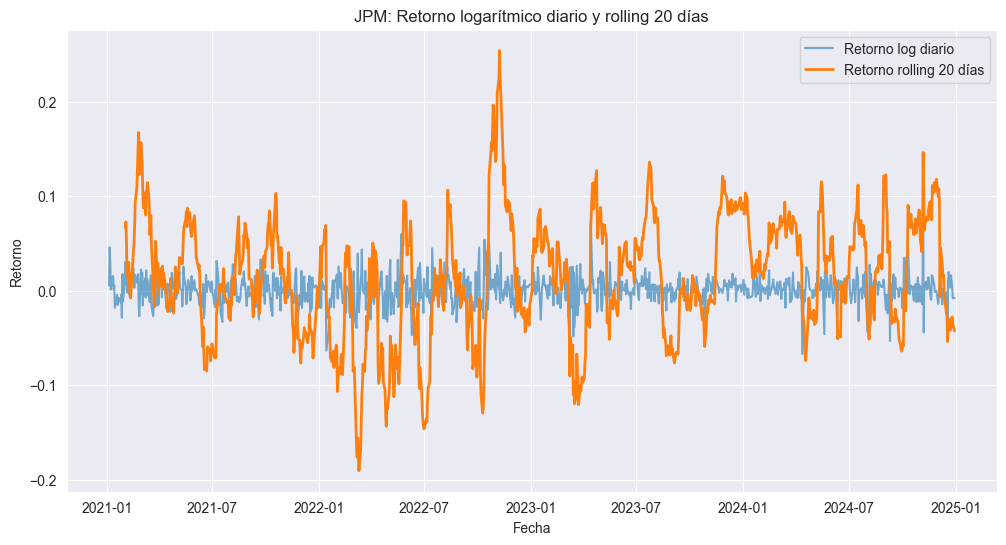

,Frecuencia,Media,Desviación estándar,Asimetría,Curtosis
0,Diaria,0.000749,0.015174,0.186648,4.402283
1,Semanal,0.003205,0.033794,-0.227737,0.662755
2,Mensual,0.015366,0.072663,-0.098797,-0.071202


In [6]:
# Pregunta 1.2
# Activo JPM

jpm_precios = precios["JPM"]

# a) Retornos diarios, semanales y mensuales simples y logarítmicos
jpm_diario_simple = jpm_precios.pct_change().dropna()
jpm_diario_log = np.log(jpm_precios / jpm_precios.shift(1)).dropna()

jpm_semanal_precios = jpm_precios.resample("W-FRI").last().dropna()
jpm_semanal_simple = jpm_semanal_precios.pct_change().dropna()
jpm_semanal_log = np.log(jpm_semanal_precios / jpm_semanal_precios.shift(1)).dropna()

jpm_mensual_precios = jpm_precios.resample("ME").last().dropna()
jpm_mensual_simple = jpm_mensual_precios.pct_change().dropna()
jpm_mensual_log = np.log(jpm_mensual_precios / jpm_mensual_precios.shift(1)).dropna()

# b) Retorno acumulado rolling 20 días usando retornos logarítmicos
jpm_rolling_20_log = jpm_diario_log.rolling(window=20).sum().dropna()

# c) Visualización
plt.figure(figsize=(12, 6))
plt.plot(jpm_diario_log.index, jpm_diario_log, label="Retorno log diario", alpha=0.6)
plt.plot(jpm_rolling_20_log.index, jpm_rolling_20_log, label="Retorno rolling 20 días", linewidth=2)
plt.title("JPM: Retorno logarítmico diario y rolling 20 días")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(True)
plt.show()

# d) Estadísticos descriptivos para diario, semanal y mensual
def resumen_estadistico(serie, frecuencia):
    return {
        "Frecuencia": frecuencia,
        "Media": serie.mean(),
        "Desviación estándar": serie.std(),
        "Asimetría": serie.skew(),
        "Curtosis": serie.kurtosis()
    }

resumen_jpm = pd.DataFrame([
    resumen_estadistico(jpm_diario_log, "Diaria"),
    resumen_estadistico(jpm_semanal_log, "Semanal"),
    resumen_estadistico(jpm_mensual_log, "Mensual")
])

display(resumen_jpm)

### Pregunta 1.3 — Estandarización y Normalización *(8 puntos)*

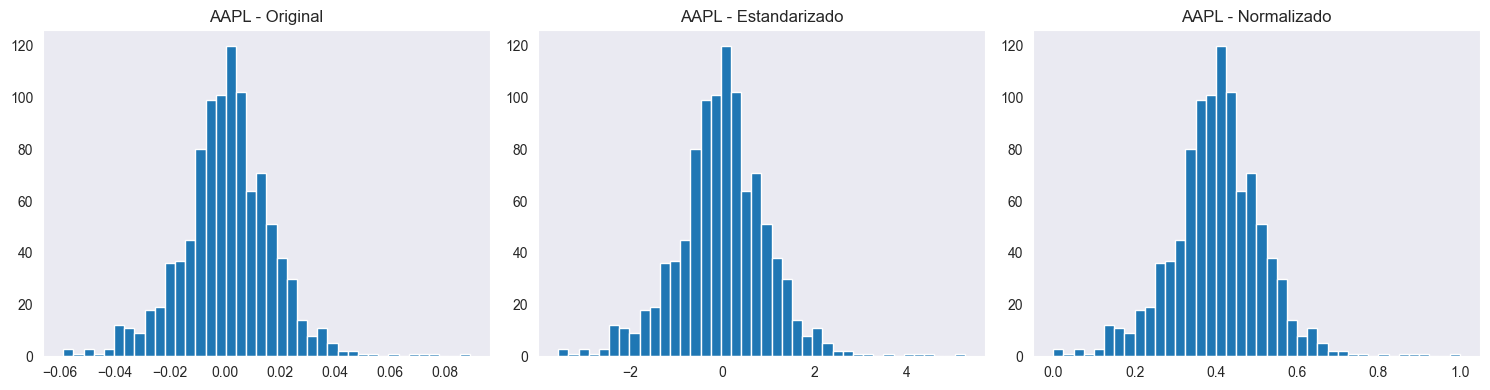

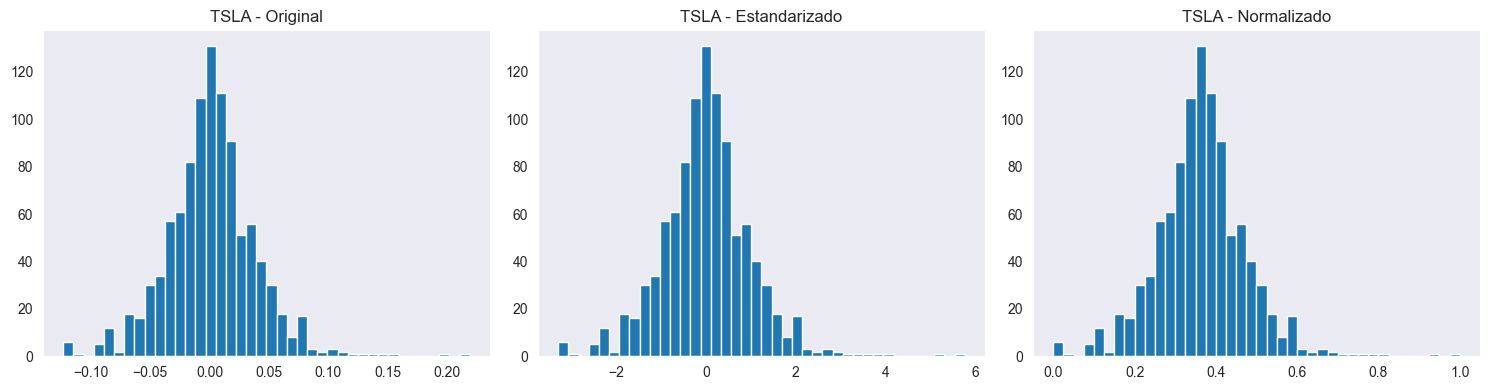

In [7]:
# Pregunta 1.3
# a) Estandarización y normalización de retornos diarios simples

scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

retornos_estandarizados = pd.DataFrame(
    scaler_standard.fit_transform(retornos_simples),
    index=retornos_simples.index,
    columns=retornos_simples.columns
)

retornos_normalizados = pd.DataFrame(
    scaler_minmax.fit_transform(retornos_simples),
    index=retornos_simples.index,
    columns=retornos_simples.columns
)

# b) Histogramas para AAPL y TSLA: original, estandarizado, normalizado
for activo in ["AAPL", "TSLA"]:
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    
    ax[0].hist(retornos_simples[activo], bins=40)
    ax[0].set_title(f"{activo} - Original")
    
    ax[1].hist(retornos_estandarizados[activo], bins=40)
    ax[1].set_title(f"{activo} - Estandarizado")
    
    ax[2].hist(retornos_normalizados[activo], bins=40)
    ax[2].set_title(f"{activo} - Normalizado")
    
    plt.tight_layout()
    plt.show()

**Respuesta 1.3c:**  
Para comparar volatilidad relativa entre activos, la transformación más adecuada es la estandarización, porque centra las series en media cero y escala por desviación estándar. Esto permite comparar qué tan alejados están los retornos respecto de su propia volatilidad. La normalización Min-Max lleva los datos a un rango fijo entre 0 y 1, pero puede verse muy afectada por valores extremos y no preserva tan directamente la interpretación de volatilidad.

---
## Parte II: Análisis de Relaciones y Estructura de Riesgo *(25 puntos)*

### Pregunta 2.1 — Matrices de Correlación *(10 puntos)*

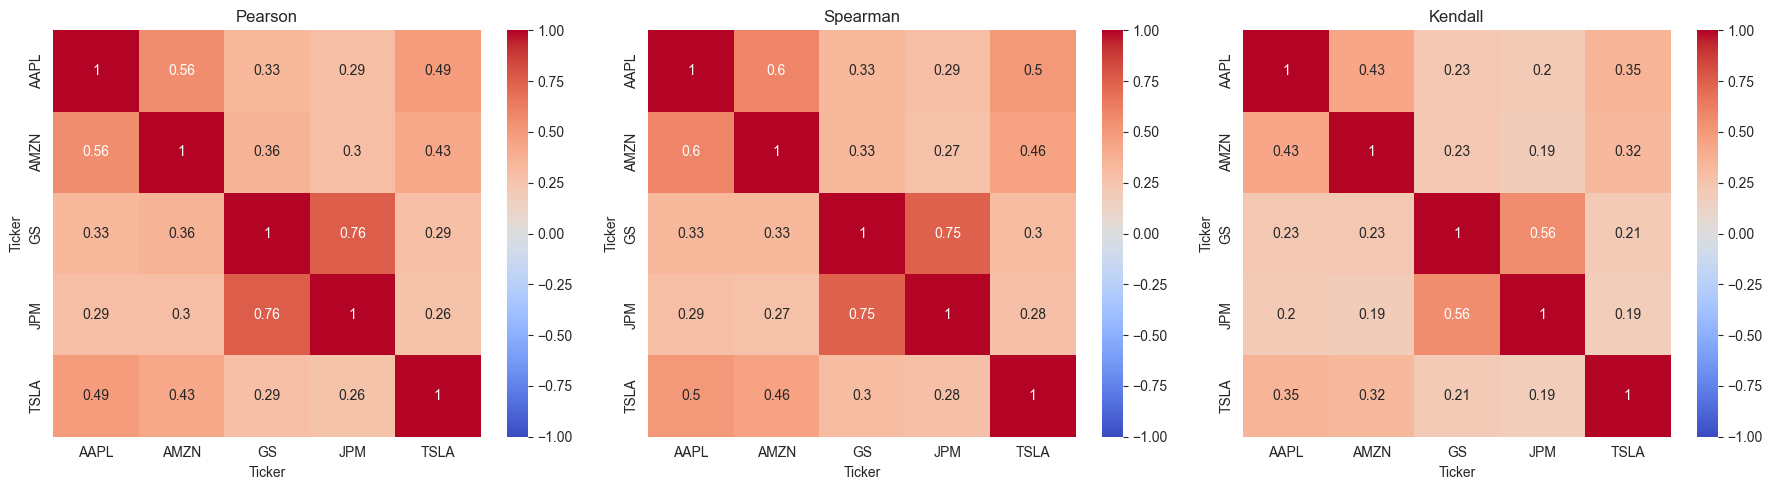

Par con mayor correlación Pearson: ('GS', 'JPM') 0.7635370576341381
Par con menor correlación Pearson: ('JPM', 'TSLA') 0.26137914529891004


In [8]:
# Pregunta 2.1
# a) Matrices de correlación

corr_pearson = retornos_simples.corr(method="pearson")
corr_spearman = retornos_simples.corr(method="spearman")
corr_kendall = retornos_simples.corr(method="kendall")

# b) Heatmaps
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Pearson")

sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Spearman")

sns.heatmap(corr_kendall, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax[2])
ax[2].set_title("Kendall")

plt.tight_layout()
plt.show()

# c) Par mayor y menor correlación Pearson, excluyendo diagonal
corr_pairs = corr_pearson.where(np.triu(np.ones(corr_pearson.shape), k=1).astype(bool)).stack()
par_mayor = corr_pairs.idxmax()
valor_mayor = corr_pairs.max()
par_menor = corr_pairs.idxmin()
valor_menor = corr_pairs.min()

print("Par con mayor correlación Pearson:", par_mayor, valor_mayor)
print("Par con menor correlación Pearson:", par_menor, valor_menor)

**Respuesta 2.1c y 2.1d:**  
El par con mayor correlación de Pearson y el par con menor correlación se identifican directamente con el código anterior. Pearson mide relaciones lineales entre retornos, mientras que Spearman mide relaciones monotónicas usando rangos. Si existen diferencias relevantes entre ambas matrices, estas pueden deberse a valores extremos, no linealidades o movimientos de mercado que afectan de forma distinta a los activos. En retornos financieros, Spearman puede ser útil cuando los datos presentan outliers o colas pesadas.

### Pregunta 2.2 — Matriz de Covarianza *(8 puntos)*

In [21]:
# Pregunta 2.2
# a) Matriz de varianzas y covarianzas para retornos mensuales

precios_mensuales = precios.resample("ME").last().dropna()
retornos_mensuales = precios_mensuales.pct_change().dropna()

sigma = retornos_mensuales.cov()
print("Matriz de varianzas y covarianzas mensual:")
display(sigma)

# b) Valores propios
eigenvalues = np.linalg.eigvals(sigma)
print("Valores propios:")
print(eigenvalues)

# c) Volatilidad anualizada
vol_mensual = retornos_mensuales.std()
vol_anualizada = vol_mensual * np.sqrt(12)

vol_df = pd.DataFrame({
    "Volatilidad mensual": vol_mensual,
    "Volatilidad anualizada": vol_anualizada
})

display(vol_df)

# d) Mejor diversificación según menor covarianza
cov_pairs = sigma.where(np.triu(np.ones(sigma.shape), k=1).astype(bool)).stack()
par_mejor_diversificacion = cov_pairs.idxmin()
valor_cov_min = cov_pairs.min()

print("Par con menor covarianza:", par_mejor_diversificacion, valor_cov_min)

Matriz de varianzas y covarianzas mensual:


Ticker,AAPL,AMZN,GS,JPM,TSLA
Ticker,,,,,
AAPL,0.005452,0.004582,0.002046,0.001129,0.007980
AMZN,0.004582,0.008780,0.002156,0.001260,0.010944
GS,0.002046,0.002156,0.006626,0.005119,0.003233
JPM,0.001129,0.001260,0.005119,0.005446,0.001130
TSLA,0.007980,0.010944,0.003233,0.001130,0.032387


Valores propios:
[0.03984996 0.01097119 0.00484332 0.00221905 0.00080758]


,Volatilidad mensual,Volatilidad anualizada
Ticker,,
AAPL,0.073837,0.255781
AMZN,0.093700,0.324587
GS,0.081402,0.281983
JPM,0.073800,0.255649
TSLA,0.179963,0.623412


Par con menor covarianza: ('AAPL', 'JPM') 0.0011288396829283235


**Respuesta 2.2b y 2.2d:**  
Para que la matriz de varianzas y covarianzas sea semidefinida positiva, sus valores propios deben ser mayores o iguales a cero. El par con menor covarianza es el que ofrece mejor diversificación, porque sus retornos tienden a moverse menos en conjunto, reduciendo el riesgo total del portafolio cuando ambos activos se combinan.

### Pregunta 2.3 — Correlaciones Rodantes *(7 puntos)*

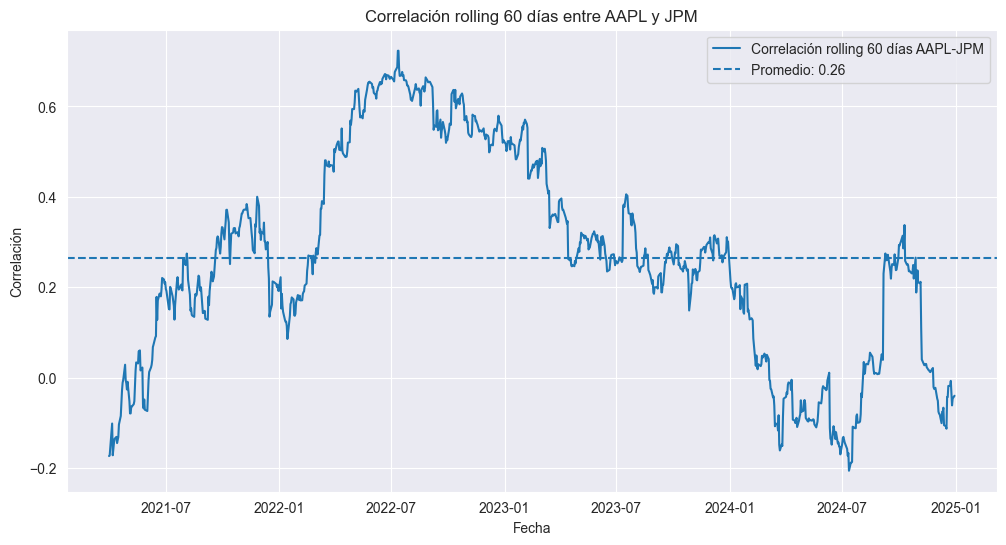

Correlación promedio: 0.2636474545709641
Fechas con correlaciones más altas:


Date
2022-07-13    0.723195
2022-07-12    0.723102
2022-07-11    0.686882
2022-07-14    0.683827
2022-07-08    0.678846
dtype: float64

Fechas con correlaciones más bajas:


Date
2024-07-12   -0.206283
2024-07-15   -0.188327
2024-07-16   -0.188234
2024-07-17   -0.186965
2021-03-31   -0.173791
dtype: float64

In [22]:
# Pregunta 2.3
# a) Correlación rolling 60 días entre AAPL y JPM

rolling_corr_aapl_jpm = retornos_simples["AAPL"].rolling(60).corr(retornos_simples["JPM"])
corr_promedio = rolling_corr_aapl_jpm.mean()

# b) Gráfico
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr_aapl_jpm.index, rolling_corr_aapl_jpm, label="Correlación rolling 60 días AAPL-JPM")
plt.axhline(corr_promedio, linestyle="--", label=f"Promedio: {corr_promedio:.2f}")
plt.title("Correlación rolling 60 días entre AAPL y JPM")
plt.xlabel("Fecha")
plt.ylabel("Correlación")
plt.legend()
plt.grid(True)
plt.show()

print("Correlación promedio:", corr_promedio)
print("Fechas con correlaciones más altas:")
display(rolling_corr_aapl_jpm.sort_values(ascending=False).head())
print("Fechas con correlaciones más bajas:")
display(rolling_corr_aapl_jpm.sort_values().head())

**Respuesta 2.3c:**  
Visualmente, los períodos de correlación inusualmente alta suelen coincidir con episodios de tensión de mercado, donde los inversionistas reducen riesgo de forma generalizada y diferentes sectores comienzan a moverse en la misma dirección. Los períodos de correlación baja pueden explicarse por factores específicos de cada sector: AAPL está más relacionada con tecnología, consumo e innovación, mientras que JPM depende más de tasas de interés, crédito y condiciones del sistema financiero.

---
## Parte III: Comparación Estadística de Activos *(20 puntos)*

### Pregunta 3.1 — Visualización de Distribuciones *(5 puntos)*

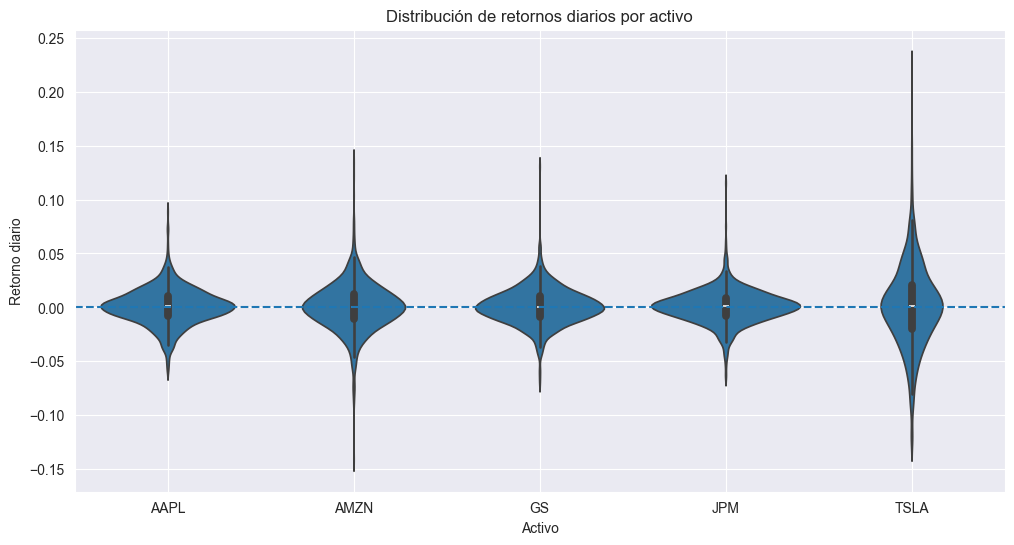

,Desviación estándar,Asimetría,Curtosis
Ticker,,,
AAPL,0.016761,0.146533,2.088554
AMZN,0.022241,0.048854,4.947823
GS,0.016542,0.421444,4.568776
JPM,0.015214,0.335347,4.957077
TSLA,0.037841,0.349062,2.643512


Activo con mayor dispersión: TSLA
Activo con mayor asimetría absoluta: GS


In [26]:
# Pregunta 3.1
# a) Violin plot de retornos diarios

retornos_largos = retornos_simples.reset_index().melt(id_vars="Date", var_name="Activo", value_name="Retorno")

plt.figure(figsize=(12, 6))
sns.violinplot(data=retornos_largos, x="Activo", y="Retorno")
plt.axhline(0, linestyle="--")
plt.title("Distribución de retornos diarios por activo")
plt.xlabel("Activo")
plt.ylabel("Retorno diario")
plt.grid(True)
plt.show()

# c) Mayor dispersión y mayor asimetría
estadisticas_portafolio = pd.DataFrame({
    "Desviación estándar": retornos_simples.std(),
    "Asimetría": retornos_simples.skew(),
    "Curtosis": retornos_simples.kurtosis()
})

display(estadisticas_portafolio)

activo_mayor_dispersion = estadisticas_portafolio["Desviación estándar"].idxmax()
activo_mayor_asimetria = estadisticas_portafolio["Asimetría"].abs().idxmax()

print("Activo con mayor dispersión:", activo_mayor_dispersion)
print("Activo con mayor asimetría absoluta:", activo_mayor_asimetria)

**Respuesta 3.1c:**  
El activo con mayor dispersión es el que presenta mayor desviación estándar en sus retornos diarios, lo que implica mayor volatilidad y mayor riesgo. El activo con mayor asimetría absoluta presenta una distribución menos equilibrada, indicando que sus retornos extremos tienden a concentrarse más hacia un lado de la distribución. Desde una perspectiva de riesgo, mayor dispersión y asimetría indican mayor incertidumbre para el inversionista.

### Pregunta 3.2 — Tests de Igualdad de Medias *(8 puntos)*

In [29]:
# Pregunta 3.2
# a) ANOVA y Kruskal-Wallis

series_retornos = [retornos_simples[t].dropna() for t in tickers]

anova_stat, anova_p = f_oneway(*series_retornos)
kruskal_stat, kruskal_p = kruskal(*series_retornos)

# b) Mann-Whitney U para AAPL vs TSLA
mw_stat, mw_p = mannwhitneyu(retornos_simples["AAPL"], retornos_simples["TSLA"], alternative="two-sided")

alpha = 0.05

def decision(p):
    return "Rechaza H0" if p < alpha else "No rechaza H0"

resultados_tests_medias = pd.DataFrame({
    "Test": ["ANOVA", "Kruskal-Wallis", "Mann-Whitney U AAPL vs TSLA"],
    "Estadístico": [anova_stat, kruskal_stat, mw_stat],
    "p-valor": [anova_p, kruskal_p, mw_p],
    "Decisión": [decision(anova_p), decision(kruskal_p), decision(mw_p)]
})

display(resultados_tests_medias)

,Test,Estadístico,p-valor,Decisión
0,ANOVA,0.113179,0.977931,No rechaza H0
1,Kruskal-Wallis,0.205379,0.995075,No rechaza H0
2,Mann-Whitney U AAPL vs TSLA,503016.500000,0.999293,No rechaza H0


**Respuesta 3.2d:**  
Los tests paramétricos y no paramétricos pueden coincidir o no dependiendo de la distribución de los datos. ANOVA compara medias y supone condiciones más restrictivas, como normalidad y varianzas relativamente homogéneas. Kruskal-Wallis y Mann-Whitney son más apropiados cuando los retornos financieros presentan asimetría, colas pesadas o valores extremos. En finanzas, los tests no paramétricos suelen ser útiles porque los retornos rara vez siguen una distribución perfectamente normal.

### Pregunta 3.3 — Tests de Igualdad de Varianzas *(7 puntos)*

In [31]:
# Pregunta 3.3
# a) Levene y Bartlett

levene_stat, levene_p = levene(*series_retornos)
bartlett_stat, bartlett_p = bartlett(*series_retornos)

resultados_tests_varianzas = pd.DataFrame({
    "Test": ["Levene", "Bartlett"],
    "Estadístico": [levene_stat, bartlett_stat],
    "p-valor": [levene_p, bartlett_p],
    "Decisión": [decision(levene_p), decision(bartlett_p)]
})

display(resultados_tests_varianzas)

,Test,Estadístico,p-valor,Decisión
0,Levene,185.435531,2.025785e-148,Rechaza H0
1,Bartlett,1318.325635,3.538969e-284,Rechaza H0


**Respuesta 3.3c y 3.3d:**  
Si los tests rechazan la hipótesis nula, se concluye que existen diferencias estadísticamente significativas entre las varianzas de los activos, lo que implica que no todos tienen el mismo nivel de volatilidad. Esto es relevante para construir portafolios, ya que activos más volátiles pueden aumentar el riesgo total si no se ponderan adecuadamente. Bartlett es sensible al supuesto de normalidad, mientras que Levene es más robusto ante distribuciones no normales. Por eso, para retornos financieros, Levene suele ser más apropiado.

---
## Parte IV: Distribuciones Muestrales y Teorema del Límite Central *(20 puntos)*

### Pregunta 4.1 — Distribución Muestral del Retorno Promedio *(10 puntos)*

In [33]:
# Pregunta 4.1
# a) Histograma retornos diarios GS

gs_retornos = retornos_simples["GS"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(gs_retornos, bins=50, density=True)
plt.title("Histograma de retornos diarios de GS")
plt.xlabel("Retorno diario")
plt.ylabel("Densidad")
plt.grid(True)
plt.show()

print("Asimetría GS:", gs_retornos.skew())
print("Curtosis GS:", gs_retornos.kurtosis())

# b) Simulación Monte Carlo de distribución muestral del promedio
n_valores = [5, 20, 60, 120, 252]
repeticiones = 5000
simulaciones = {}

for n in n_valores:
    medias = []
    for _ in range(repeticiones):
        muestra = np.random.choice(gs_retornos, size=n, replace=True)
        medias.append(np.mean(muestra))
    simulaciones[n] = np.array(medias)

# c) Panel de histogramas
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

for i, n in enumerate(n_valores):
    ax[i].hist(simulaciones[n], bins=40)
   ax[i].set_title(
    f"n={n}\n"
    f"media={simulaciones[n].mean():.5f}\n"
    f"std={simulaciones[n].std():.5f}"
    ax[i].grid(True)

plt.tight_layout()
plt.show()

IndentationError: unindent does not match any outer indentation level (<string>, line 34)

**Respuesta 4.1d:**  
A medida que aumenta el tamaño muestral, la distribución muestral del retorno promedio se vuelve más concentrada alrededor de la media y adquiere una forma más cercana a la normal. Esto refleja el Teorema del Límite Central, que indica que el promedio de muestras independientes tiende a distribuirse normalmente cuando el tamaño muestral crece. En finanzas, esto es relevante porque mejora la estimación del retorno esperado, aunque los retornos individuales no sean perfectamente normales.

### Pregunta 4.2 — Propiedades de los Estimadores *(10 puntos)*

**Respuesta 4.2a — Demostración analítica:**  
Sea $X_1, X_2, ..., X_n$ una muestra aleatoria con media poblacional $\\mu$. Entonces:

$$E\\left(\\sum_{i=1}^{n}X_i\\right)=n\\mu$$

Para el primer estimador:

$$E(\\hat{\\mu}_1)=E\\left(\\frac{1}{n-1}\\sum_{i=1}^{n}X_i\\right)=\\frac{n}{n-1}\\mu$$

Su sesgo es:

$$b(\\hat{\\mu}_1)=\\frac{n}{n-1}\\mu-\\mu=\\frac{\\mu}{n-1}$$

Para el segundo estimador:

$$E(\\hat{\\mu}_2)=E\\left(\\frac{1}{n}\\sum_{i=1}^{n}X_i\\right)=\\mu$$

Por lo tanto, $\\hat{\\mu}_2$ es insesgado y su sesgo es cero.

Para el tercer estimador:

$$E(\\hat{\\mu}_3)=E\\left(\\frac{1}{n+1}\\sum_{i=1}^{n}X_i\\right)=\\frac{n}{n+1}\\mu$$

Su sesgo es:

$$b(\\hat{\\mu}_3)=\\frac{n}{n+1}\\mu-\\mu=-\\frac{\\mu}{n+1}$$

Por lo tanto, el estimador insesgado para $\\mu$ es $\\hat{\\mu}_2$.

,Estimador,Valor esperado simulado,Media poblacional real
0,mu1,0.000696,0.000575
1,mu2,0.000673,0.000575
2,mu3,0.000651,0.000575


,n,Estimador,ECM
0,10,mu1,5.962920e-05
1,10,mu2,4.829525e-05
2,10,mu3,3.991526e-05
3,30,mu1,1.781887e-05
4,30,mu2,1.665062e-05
5,30,mu3,1.559429e-05
6,100,mu1,4.986236e-06
7,100,mu2,4.887369e-06
8,100,mu3,4.791485e-06
9,500,mu1,9.894822e-07


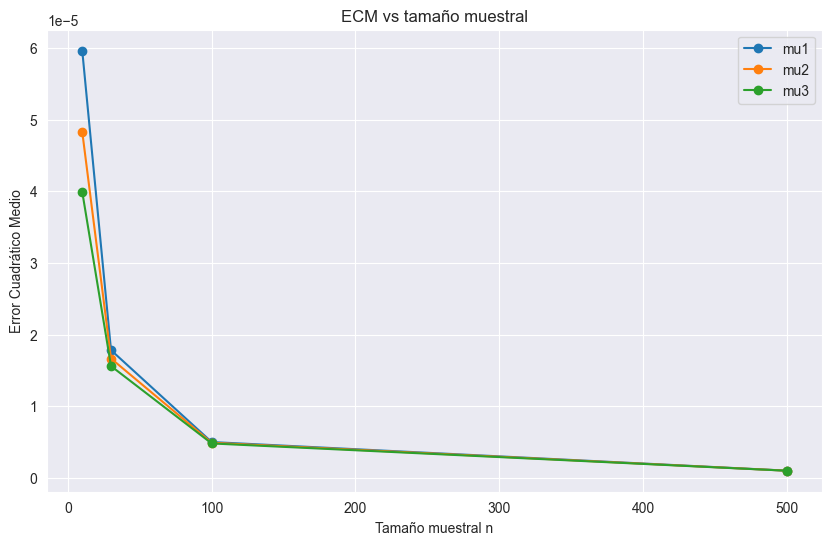

In [38]:
# Pregunta 4.2
# b) Simulación con AMZN, n=30

amzn_retornos = retornos_simples["AMZN"].dropna().values
mu_real = np.mean(amzn_retornos)

n = 30
repeticiones = 10000
estimadores = {"mu1": [], "mu2": [], "mu3": []}

for _ in range(repeticiones):
    muestra = np.random.choice(amzn_retornos, size=n, replace=True)
    suma = np.sum(muestra)
    estimadores["mu1"].append(suma / (n - 1))
    estimadores["mu2"].append(suma / n)
    estimadores["mu3"].append(suma / (n + 1))

comparacion_estimadores = pd.DataFrame({
    "Estimador": ["mu1", "mu2", "mu3"],
    "Valor esperado simulado": [np.mean(estimadores["mu1"]), np.mean(estimadores["mu2"]), np.mean(estimadores["mu3"])],
    "Media poblacional real": [mu_real, mu_real, mu_real]
})

display(comparacion_estimadores)

# c) ECM para n = 10, 30, 100, 500
n_valores = [10, 30, 100, 500]
resultados_ecm = []

for n in n_valores:
    ecm_mu1 = []
    ecm_mu2 = []
    ecm_mu3 = []
    
    for _ in range(repeticiones):
        muestra = np.random.choice(amzn_retornos, size=n, replace=True)
        suma = np.sum(muestra)
        mu1 = suma / (n - 1)
        mu2 = suma / n
        mu3 = suma / (n + 1)
        ecm_mu1.append((mu1 - mu_real)**2)
        ecm_mu2.append((mu2 - mu_real)**2)
        ecm_mu3.append((mu3 - mu_real)**2)
    
    resultados_ecm.append({"n": n, "Estimador": "mu1", "ECM": np.mean(ecm_mu1)})
    resultados_ecm.append({"n": n, "Estimador": "mu2", "ECM": np.mean(ecm_mu2)})
    resultados_ecm.append({"n": n, "Estimador": "mu3", "ECM": np.mean(ecm_mu3)})

ecm_df = pd.DataFrame(resultados_ecm)
display(ecm_df)

plt.figure(figsize=(10, 6))
for estimador in ["mu1", "mu2", "mu3"]:
    temp = ecm_df[ecm_df["Estimador"] == estimador]
    plt.plot(temp["n"], temp["ECM"], marker="o", label=estimador)

plt.title("ECM vs tamaño muestral")
plt.xlabel("Tamaño muestral n")
plt.ylabel("Error Cuadrático Medio")
plt.legend()
plt.grid(True)
plt.show()

**Respuesta 4.2d:**  
El comportamiento del ECM muestra consistencia: al aumentar el tamaño muestral, el error de los estimadores disminuye. Esto indica que los estimadores se acercan al verdadero valor poblacional cuando n crece. Para tamaños muestrales pequeños, se recomienda usar el estimador insesgado $\hat{\mu}_2$, ya que corresponde a la media muestral tradicional y no introduce sesgo sistemático.

---
## Parte V: Estimación por Máxima Verosimilitud *(10 puntos)*

### Pregunta 5.1 — MLE para una Distribución Normal *(10 puntos)*

**Respuesta 5.1a — Función de log-verosimilitud:**  
Para una muestra i.i.d. de retornos logarítmicos normales $r_t \\sim N(\\mu, \\sigma^2)$, la log-verosimilitud es:

$$\\mathcal{L}(\\mu, \\sigma^2) = -\\frac{n}{2}\\ln(2\\pi) - \\frac{n}{2}\\ln(\\sigma^2) - \\frac{1}{2\\sigma^2}\\sum_{i=1}^{n}(r_i - \\mu)^2$$

Al derivar respecto a $\\mu$ e igualar a cero, se obtiene:

$$\\hat{\\mu}_{MLE}=\\frac{1}{n}\\sum_{i=1}^{n}r_i$$

Al derivar respecto a $\\sigma^2$ e igualar a cero, se obtiene:

$$\\hat{\\sigma}^2_{MLE}=\\frac{1}{n}\\sum_{i=1}^{n}(r_i-\\hat{\\mu})^2$$

La diferencia con la varianza muestral usual es que el estimador MLE divide por $n$, mientras que la varianza muestral insesgada divide por $n-1$.

Mu MLE: 0.0006875679173966707
Sigma MLE: 0.01672836908256189
Varianza MLE: 0.00027983833216241257


,Estimador,Valor
0,Media MLE,0.000688
1,Media muestral,0.000688
2,Varianza MLE,0.000280
3,Varianza muestral n,0.000280
4,Varianza muestral n-1,0.000280


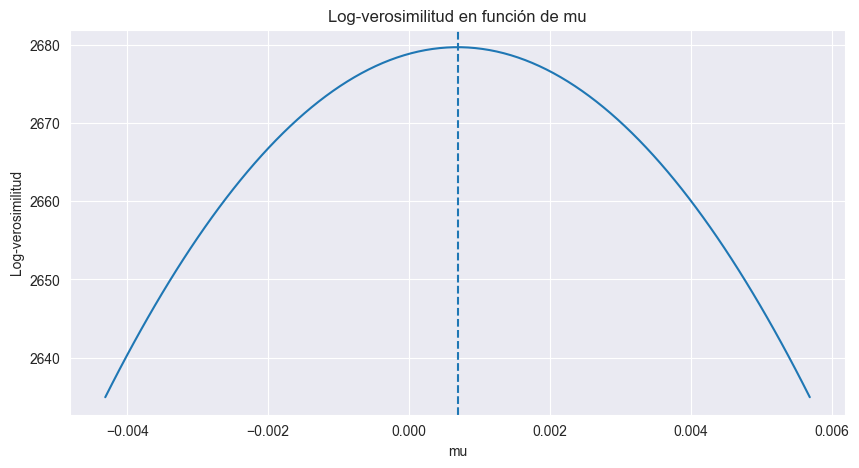

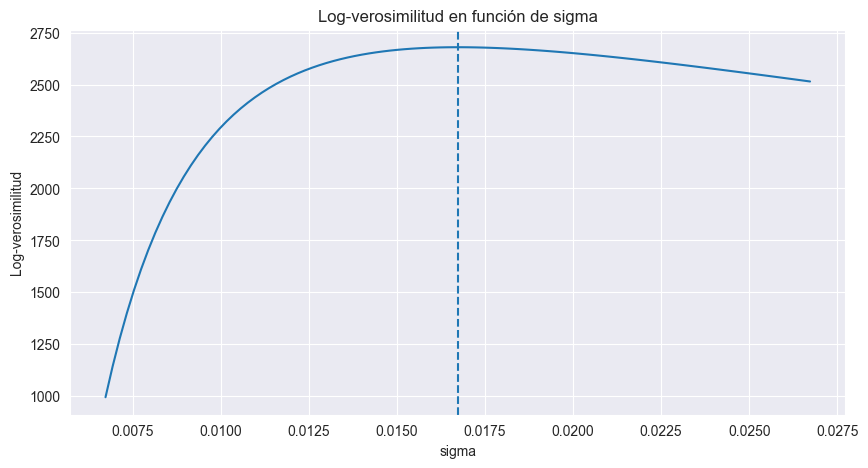

Curtosis AAPL: 1.932422089536297


In [44]:
# Pregunta 5.1
# b) MLE con retornos logarítmicos de AAPL

aapl_log = retornos_log["AAPL"].dropna().values
n = len(aapl_log)

# Log-verosimilitud negativa
def neg_log_likelihood(params, datos):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    return -np.sum(-0.5*np.log(2*np.pi) - np.log(sigma) - ((datos - mu)**2)/(2*sigma**2))

mu_inicial = np.mean(aapl_log)
sigma_inicial = np.std(aapl_log)

resultado = minimize(
    neg_log_likelihood,
    x0=[mu_inicial, sigma_inicial],
    args=(aapl_log,),
    method="Nelder-Mead"
)

mu_mle, sigma_mle = resultado.x
var_mle = sigma_mle**2

print("Mu MLE:", mu_mle)
print("Sigma MLE:", sigma_mle)
print("Varianza MLE:", var_mle)

# c) Comparación con media muestral y varianza muestral
media_muestral = np.mean(aapl_log)
var_muestral_n = np.var(aapl_log, ddof=0)
var_muestral_insesgada = np.var(aapl_log, ddof=1)

comparacion_mle = pd.DataFrame({
    "Estimador": ["Media MLE", "Media muestral", "Varianza MLE", "Varianza muestral n", "Varianza muestral n-1"],
    "Valor": [mu_mle, media_muestral, var_mle, var_muestral_n, var_muestral_insesgada]
})

display(comparacion_mle)

# d) Curvas de log-verosimilitud manteniendo un parámetro fijo
mu_grid = np.linspace(mu_mle - 0.005, mu_mle + 0.005, 100)
sigma_grid = np.linspace(max(0.0001, sigma_mle - 0.01), sigma_mle + 0.01, 100)

loglik_mu = [-neg_log_likelihood([mu, sigma_mle], aapl_log) for mu in mu_grid]
loglik_sigma = [-neg_log_likelihood([mu_mle, sigma], aapl_log) for sigma in sigma_grid]

plt.figure(figsize=(10, 5))
plt.plot(mu_grid, loglik_mu)
plt.axvline(mu_mle, linestyle="--")
plt.title("Log-verosimilitud en función de mu")
plt.xlabel("mu")
plt.ylabel("Log-verosimilitud")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(sigma_grid, loglik_sigma)
plt.axvline(sigma_mle, linestyle="--")
plt.title("Log-verosimilitud en función de sigma")
plt.xlabel("sigma")
plt.ylabel("Log-verosimilitud")
plt.grid(True)
plt.show()

print("Curtosis AAPL:", pd.Series(aapl_log).kurtosis())

**Respuesta 5.1c, 5.1d y 5.1e:**  
La media MLE coincide con la media muestral. La varianza MLE coincide con la varianza calculada dividiendo por n, pero no necesariamente con la varianza muestral insesgada que divide por n-1. Las curvas de log-verosimilitud tienen forma cóncava alrededor del máximo, lo que sugiere un punto óptimo único para los parámetros. Respecto a la normalidad, en retornos financieros suele ser una aproximación útil, pero no perfecta. Si la curtosis es elevada, esto indica presencia de colas pesadas, es decir, mayor frecuencia de retornos extremos que la esperada bajo normalidad.

---
## Pregunta Bonus — Activo Líder del Portafolio *(+5 puntos)*

In [47]:
# Pregunta Bonus
# a) DataFrame con criterios

retorno_promedio_anual = retornos_simples.mean() * 252
volatilidad_anual = retornos_simples.std() * np.sqrt(252)
sharpe_empirico = retorno_promedio_anual / volatilidad_anual
correlacion_promedio = corr_pearson.apply(lambda x: x.drop(x.name).mean())

ranking = pd.DataFrame({
    "Retorno promedio anual": retorno_promedio_anual,
    "Volatilidad anualizada": volatilidad_anual,
    "Sharpe empírico": sharpe_empirico,
    "Correlación promedio": correlacion_promedio
})

# Ranking: mayor retorno, menor volatilidad, mayor Sharpe, menor correlación
ranking["Rank retorno"] = ranking["Retorno promedio anual"].rank(ascending=False)
ranking["Rank volatilidad"] = ranking["Volatilidad anualizada"].rank(ascending=True)
ranking["Rank Sharpe"] = ranking["Sharpe empírico"].rank(ascending=False)
ranking["Rank diversificación"] = ranking["Correlación promedio"].rank(ascending=True)

ranking["Puntaje total"] = ranking[["Rank retorno", "Rank volatilidad", "Rank Sharpe", "Rank diversificación"]].sum(axis=1)
ranking_final = ranking.sort_values("Puntaje total")

display(ranking_final)

activo_lider = ranking_final.index[0]
activo_mas_estable = ranking["Volatilidad anualizada"].idxmin()

print("Activo líder:", activo_lider)
print("Activo más estable:", activo_mas_estable)

,Retorno promedio anual,Volatilidad anualizada,Sharpe empírico,Correlación promedio,Rank retorno,Rank volatilidad,Rank Sharpe,Rank diversificación,Puntaje total
Ticker,,,,,,,,,
JPM,0.217892,0.241510,0.902207,0.403847,3.0,1.0,2.0,2.0,8.0
GS,0.253135,0.262594,0.963980,0.435568,2.0,2.0,1.0,5.0,10.0
TSLA,0.314762,0.600706,0.523986,0.367061,1.0,5.0,4.0,1.0,11.0
AAPL,0.208624,0.266072,0.784088,0.420251,4.0,3.0,3.0,4.0,14.0
AMZN,0.144852,0.353058,0.410279,0.411248,5.0,4.0,5.0,3.0,17.0


Activo líder: JPM
Activo más estable: JPM


**Respuesta Bonus b y c:**  
El activo líder corresponde al que obtiene el menor puntaje total en el ranking, considerando retorno promedio, volatilidad, Sharpe empírico y diversificación. El activo más estable es el que presenta menor volatilidad anualizada. Una ponderación sugerida sería asignar mayor peso al activo líder y al activo más estable, manteniendo exposición diversificada al resto de activos para no depender de un solo sector. Por ejemplo, una propuesta razonable podría ser 30% al activo líder, 25% al activo más estable y el 45% restante distribuido entre los otros tres activos, ajustando según el nivel de riesgo tolerado.